# **Cuaderno 6.2 Gradiente en descenso**

Este cuaderno recrea el algoritmo de gradiente en descenso como se muestra en la figura 6.1.

Trabaje a través de las celdas a continuación, ejecutando cada celda a su vez. En varios lugares verá las palabras "TO DO". Siga las instrucciones en estos lugares y haga predicciones sobre lo que va a suceder o escriba código para completar las funciones.

Contáctame en udlbookmail@gmail.com si encuentras algún error o tienes alguna sugerencia.

In [1]:
# importar librerias
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

In [2]:
# Creemos nuestros datos de entrenamiento 12 pares {x_i, y_i}
# Intentaremos ajustar el modelo de línea recta a estos datos
data = np.array([[0.03,0.19,0.34,0.46,0.78,0.81,1.08,1.18,1.39,1.60,1.65,1.90],
                 [0.67,0.85,1.05,1.00,1.40,1.50,1.30,1.54,1.55,1.68,1.73,1.60]])

In [3]:
data

array([[0.03, 0.19, 0.34, 0.46, 0.78, 0.81, 1.08, 1.18, 1.39, 1.6 , 1.65,
        1.9 ],
       [0.67, 0.85, 1.05, 1.  , 1.4 , 1.5 , 1.3 , 1.54, 1.55, 1.68, 1.73,
        1.6 ]])

In [4]:
# Definamos nuestro modelo -- solo una línea recta con intercepto phi[0] y pendiente phi[1]
def model(phi,x):
  y_pred = phi[0]+phi[1] * x
  return y_pred

In [5]:
# Dibujar modelo
def draw_model(data,model,phi,title=None):
  x_model = np.arange(0,2,0.01)
  y_model = model(phi,x_model)

  fix, ax = plt.subplots()
  ax.plot(data[0,:],data[1,:],'bo')
  ax.plot(x_model,y_model,'m-')
  ax.set_xlim([0,2]);ax.set_ylim([0,2])
  ax.set_xlabel('x'); ax.set_ylabel('y')
  ax.set_aspect('equal')
  if title is not None:
    ax.set_title(title)
  plt.show()

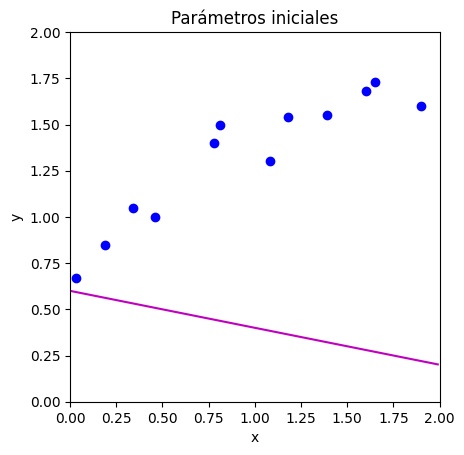

In [6]:
# Inicialice los parámetros con algunos valores arbitrarios y dibuje el modelo
phi = np.zeros((2,1))
phi[0] = 0.6      # Intercepto
phi[1] = -0.2      # Pendiente
draw_model(data,model,phi, "Parámetros iniciales")

Ahora calculemos la pérdida de la suma de cuadrados para los datos de entrenamiento

In [7]:
def compute_loss(data_x, data_y, model, phi):
  # TODO -- Escriba esta función -- reemplace la línea de abajo
  # Primero haga predicciones del modelo a partir de los datos x
  # Luego calcule la diferencia al cuadrado entre las predicciones y los valores y verdaderos
  # Luego súmelos todos y retorne
  pred_y = model(phi,data_x)

  sqdf = (pred_y - data_y) ** 2

  loss = sum(sqdf)

  return loss

Solo probemos que lo hicimos bien

In [8]:
loss = compute_loss(data[0,:],data[1,:],model,np.array([[0.6],[-0.2]]))
print('Su pérdida = %3.3f, Pérdida correcta = %3.3f'%(loss, 12.367))

Su pérdida = 12.367, Pérdida correcta = 12.367


Ahora grafiquemos toda la función de pérdida

In [9]:
def draw_loss_function(compute_loss, data,  model, phi_iters = None):
  # Define un mapa de color bonito
  my_colormap_vals_hex =('2a0902', '2b0a03', '2c0b04', '2d0c05', '2e0c06', '2f0d07', '300d08', '310e09', '320f0a', '330f0b', '34100b', '35110c', '36110d', '37120e', '38120f', '39130f', '3a1410', '3b1411', '3c1511', '3d1612', '3e1613', '3f1713', '401714', '411814', '421915', '431915', '451a16', '461b16', '471b17', '481c17', '491d18', '4a1d18', '4b1e19', '4c1f19', '4d1f1a', '4e201b', '50211b', '51211c', '52221c', '53231d', '54231d', '55241e', '56251e', '57261f', '58261f', '592720', '5b2821', '5c2821', '5d2922', '5e2a22', '5f2b23', '602b23', '612c24', '622d25', '632e25', '652e26', '662f26', '673027', '683027', '693128', '6a3229', '6b3329', '6c342a', '6d342a', '6f352b', '70362c', '71372c', '72372d', '73382e', '74392e', '753a2f', '763a2f', '773b30', '783c31', '7a3d31', '7b3e32', '7c3f33', '7d4034', '7e4134', '7f4235', '804236', '814336', '824437', '834538', '854638', '864739', '87473a', '88483a', '89493b', '8a4a3c', '8b4b3c', '8c4c3d', '8d4c3e', '8e4d3f', '8f4e3f', '904f40', '925041', '935141', '945242', '955343', '965343', '975444', '985545', '995646', '9b5746', '9c5847', '9d5948', '9e5a49', '9f5a49', 'a05b4a', 'a15c4b', 'a35d4b', 'a45e4c', 'a55f4d', 'a6604e', 'a7614e', 'a8624f', 'a96350', 'aa6451', 'ab6552', 'ac6552', 'ad6653', 'ae6754', 'af6855', 'b06955', 'b16a56', 'b26b57', 'b36c58', 'b46d59', 'b56e59', 'b66f5a', 'b7705b', 'b8715c', 'b9725d', 'ba735d', 'bb745e', 'bc755f', 'bd7660', 'be7761', 'bf7862', 'c07962', 'c17a63', 'c27b64', 'c27c65', 'c37d66', 'c47e67', 'c57f68', 'c68068', 'c78169', 'c8826a', 'c9836b', 'ca846c', 'cb856d', 'cc866e', 'cd876f', 'ce886f', 'ce8970', 'cf8a71', 'd08b72', 'd18c73', 'd28d74', 'd38e75', 'd48f76', 'd59077', 'd59178', 'd69279', 'd7937a', 'd8957b', 'd9967b', 'da977c', 'da987d', 'db997e', 'dc9a7f', 'dd9b80', 'de9c81', 'de9d82', 'df9e83', 'e09f84', 'e1a185', 'e2a286', 'e2a387', 'e3a488', 'e4a589', 'e5a68a', 'e5a78b', 'e6a88c', 'e7aa8d', 'e7ab8e', 'e8ac8f', 'e9ad90', 'eaae91', 'eaaf92', 'ebb093', 'ecb295', 'ecb396', 'edb497', 'eeb598', 'eeb699', 'efb79a', 'efb99b', 'f0ba9c', 'f1bb9d', 'f1bc9e', 'f2bd9f', 'f2bfa1', 'f3c0a2', 'f3c1a3', 'f4c2a4', 'f5c3a5', 'f5c5a6', 'f6c6a7', 'f6c7a8', 'f7c8aa', 'f7c9ab', 'f8cbac', 'f8ccad', 'f8cdae', 'f9ceb0', 'f9d0b1', 'fad1b2', 'fad2b3', 'fbd3b4', 'fbd5b6', 'fbd6b7', 'fcd7b8', 'fcd8b9', 'fcdaba', 'fddbbc', 'fddcbd', 'fddebe', 'fddfbf', 'fee0c1', 'fee1c2', 'fee3c3', 'fee4c5', 'ffe5c6', 'ffe7c7', 'ffe8c9', 'ffe9ca', 'ffebcb', 'ffeccd', 'ffedce', 'ffefcf', 'fff0d1', 'fff2d2', 'fff3d3', 'fff4d5', 'fff6d6', 'fff7d8', 'fff8d9', 'fffada', 'fffbdc', 'fffcdd', 'fffedf', 'ffffe0')
  my_colormap_vals_dec = np.array([int(element,base=16) for element in my_colormap_vals_hex])
  r = np.floor(my_colormap_vals_dec/(256*256))
  g = np.floor((my_colormap_vals_dec - r *256 *256)/256)
  b = np.floor(my_colormap_vals_dec - r * 256 *256 - g * 256)
  my_colormap = ListedColormap(np.vstack((r,g,b)).transpose()/255.0)

  # Malla de valores pendiente/interseccion
  intercepts_mesh, slopes_mesh = np.meshgrid(np.arange(0.0,2.0,0.02), np.arange(-1.0,1.0,0.002))
  loss_mesh = np.zeros_like(slopes_mesh)

  # Calcular la pérdida para cada conjunto de parámetros
  for idslope, slope in np.ndenumerate(slopes_mesh):
     loss_mesh[idslope] = compute_loss(data[0,:], data[1,:], model, np.array([[intercepts_mesh[idslope]], [slope]]))

  fig,ax = plt.subplots()
  fig.set_size_inches(8,8)
  ax.contourf(intercepts_mesh,slopes_mesh,loss_mesh,256,cmap=my_colormap)
  ax.contour(intercepts_mesh,slopes_mesh,loss_mesh,40,colors=['#80808080'])
  if phi_iters is not None:
    ax.plot(phi_iters[0,:], phi_iters[1,:],'go-')
  ax.set_ylim([1,-1])
  ax.set_xlabel('Intercepto $\phi_{0}$'); ax.set_ylabel('Pendiente, $\phi_{1}$', )
  plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3081/863962170.py:25: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('Intercepto $\phi_{0}$'); ax.set_ylabel('Pendiente, $\phi_{1}$', )
/tmp/ipykernel_3081/863962170.py:25: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('Intercepto $\phi_{0}$'); ax.set_ylabel('Pendiente, $\phi_{1}$', )


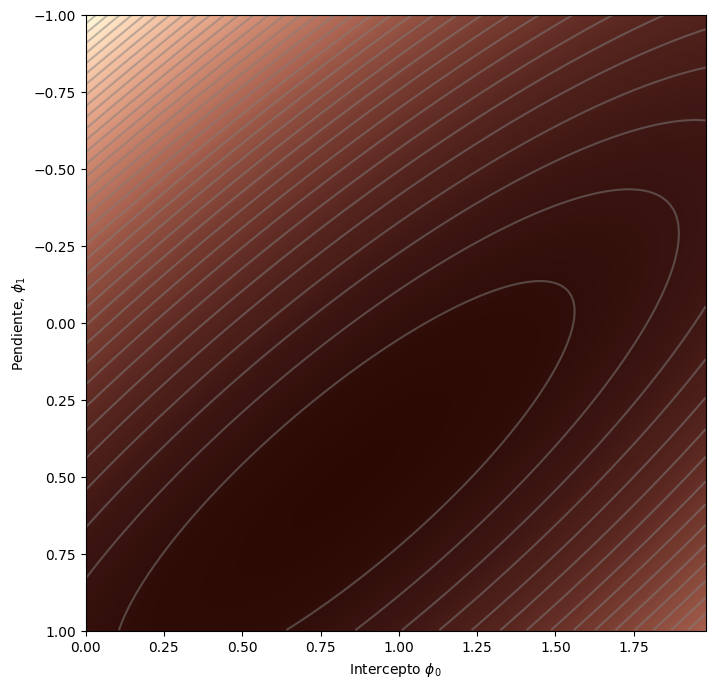

In [10]:
draw_loss_function(compute_loss, data, model)

Ahora calculemos el vector gradiente para un conjunto dado de parámetros:

\begin{equation}
\frac{\partial L}{\partial \boldsymbol\phi} = \begin{bmatrix}\frac{\partial L}{\partial \phi_0} \\ \frac{\partial L}{\partial \phi_1} \end{bmatrix}.
\end{equation}

In [11]:
# Esto está en las diapositivas y notas de la clase, pero vale la pena intentar calcularlas usted mismo para
# verificar que los obtenga correctamente. Escriba la expresión para la pérdida de la suma de cuadrados y tome la
# derivada con respecto a phi0 y phi1
def compute_gradient(data_x, data_y, phi):
    # TODO -- escriba esta función, reemplazando las líneas de abajo --- página 80, capítulo 6
    dl_dphi0 = sum(2 * (phi[0] + (phi[1] * data_x) - data_y))
    dl_dphi1 = sum(2 * data_x * (phi[0] + (phi[1] * data_x) - data_y))

    # Retornar el gradiente
    return np.array([[dl_dphi0],[dl_dphi1]])

Podemos verificar que lo hicimos bien usando un truco conocido como **diferencias finitas**. Si evaluamos la función y luego cambiamos uno de los parámetros por una cantidad muy pequeña y normalizamos por esa cantidad, obtenemos una aproximación al gradiente, así:

\begin{eqnarray}
\frac{\partial L}{\partial \phi_{0}}&\approx & \frac{L[\phi_0+\delta, \phi_1]-L[\phi_0, \phi_1]}{\delta}\\
\frac{\partial L}{\partial \phi_{1}}&\approx & \frac{L[\phi_0, \phi_1+\delta]-L[\phi_0, \phi_1]}{\delta}
\end{eqnarray}

No podemos hacer esto cuando hay muchos parámetros; para un millón de parámetros, tendríamos que evaluar la función de pérdida dos millones de veces, y usualmente calcular los gradientes directamente es mucho más eficiente.

In [12]:
# Calcule el gradiente usando su función
gradient = compute_gradient(data[0,:],data[1,:], phi)

In [13]:
gradient

array([[-21.904  ],
       [-26.84044]])

In [14]:
print("Sus gradientes: (%3.3f,%3.3f)"%(gradient[0],gradient[1]))

Sus gradientes: (-21.904,-26.840)


/tmp/ipykernel_3081/2501711034.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Sus gradientes: (%3.3f,%3.3f)"%(gradient[0],gradient[1]))


In [15]:
# Aproxime los gradientes con diferencias finitas
delta = 0.0001
dl_dphi0_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[delta],[0]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
dl_dphi1_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[0],[delta]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
print("Gradientes aproximados: (%3.3f,%3.3f)"%(dl_dphi0_est,dl_dphi1_est))
# Podría haber pequeñas diferencias en la última cifra significativa porque las diferencias finitas son una aproximación

Gradientes aproximados: (-21.903,-26.839)


Ahora estamos listos para realizar Gradient descent. Necesitaremos usar nuestra rutina de búsqueda de línea del cuaderno 6.1, que he reproducido aquí, más la función auxiliar loss_function_1D que convierte un problema 2D en un problema 1D

In [16]:
def loss_function_1D(dist_prop, data, model, phi_start, gradient):
  # Retorna la pérdida después de moverse esta distancia
  return compute_loss(data[0,:], data[1,:], model, phi_start+ gradient * dist_prop)

In [20]:
def line_search(data, model, phi, gradient, thresh=.00001, max_dist = 0.1, max_iter = 15, verbose=False):
    # Inicialice cuatro puntos a lo largo del rango que vamos a buscar
    a = 0
    b = 0.33 * max_dist
    c = 0.66 * max_dist
    d = 1.0 * max_dist
    n_iter  =0;

    # Mientras no hayamos encontrado el mínimo con suficiente precisión
    while np.abs(b-c) > thresh and n_iter < max_iter:
        # Incrementar el contador de iteraciones (solo para evitar un bucle infinito)
        n_iter = n_iter+1
        # Calcular los cuatro puntos
        lossa = loss_function_1D(a, data, model, phi,gradient)
        lossb = loss_function_1D(b, data, model, phi,gradient)
        lossc = loss_function_1D(c, data, model, phi,gradient)
        lossd = loss_function_1D(d, data, model, phi,gradient)

        if verbose:
          print('Iteración %d, a=%3.3f, b=%3.3f, c=%3.3f, d=%3.3f'%(n_iter, a,b,c,d))
          print('a %f, b%f, c%f, d%f'%(lossa,lossb,lossc,lossd))

        # Regla #1 Si el punto A es menor que los puntos B, C y D, entonces divida B,C y D por la mitad
        if np.argmin((lossa,lossb,lossc,lossd))==0:
          b = b/2
          c = c/2
          d = d/2
          continue;

        # Regla #2 Si el punto b es menor que el punto c entonces
        #                     entonces el punto d se convierte en el punto c, y
        #                     el punto b se convierte en 1/3 entre a y el nuevo d
        #                     el punto c se convierte en 2/3 entre a y el nuevo d
        if lossb.all() < lossc.all():
          d = c
          b = a+ (d-a)/3
          c = a+ 2*(d-a)/3
          continue

        # Regla #3 Si el punto c es menor que el punto b entonces
        #                     entonces el punto a se convierte en el punto b, y
        #                     el punto b se convierte en 1/3 entre el nuevo a y d
        #                     el punto c se convierte en 2/3 entre el nuevo a y d
        a = b
        b = a+ (d-a)/3
        c = a+ 2*(d-a)/3

    # Retorna el promedio de los dos puntos medios
    return (b+c)/2.0

In [18]:
def gradient_descent_step(phi, data,  model):
  # Paso 1: Calcule el gradiente
  gradient = compute_gradient(data[0,:],data[1,:], phi)
  # Paso 2: Actualice los parámetros -- tenga en cuenta que queremos buscar en la dirección negativa (cuesta abajo)
  alpha = line_search(data, model, phi, gradient*-1, max_dist = 2.0)
  phi = phi - alpha * gradient
  return phi

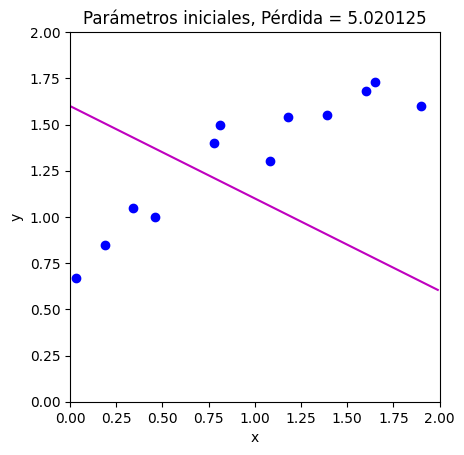

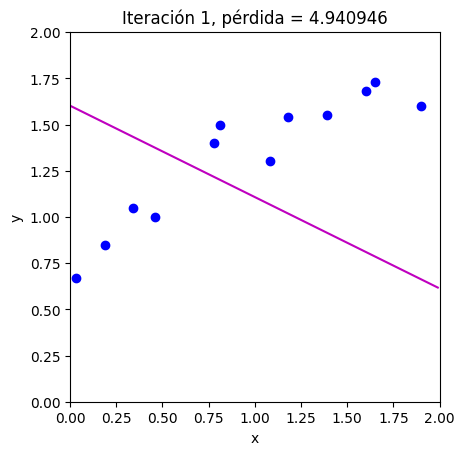

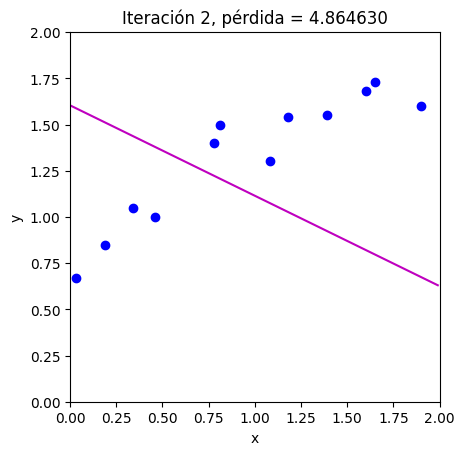

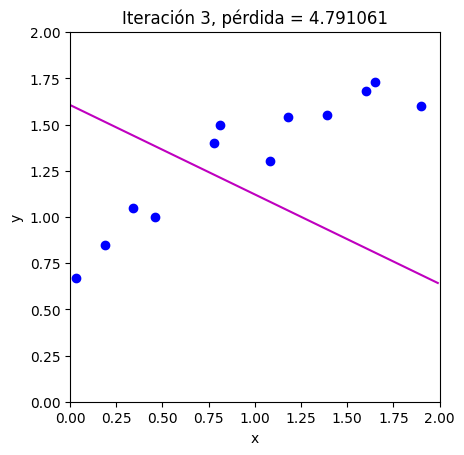

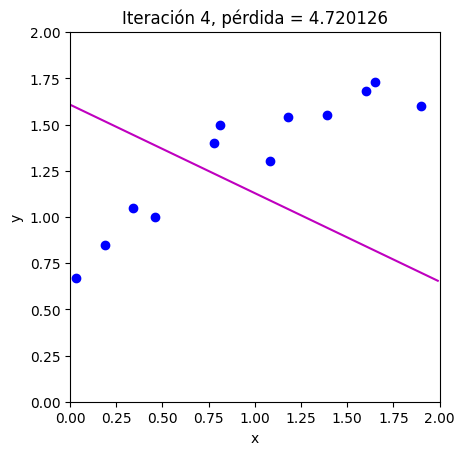

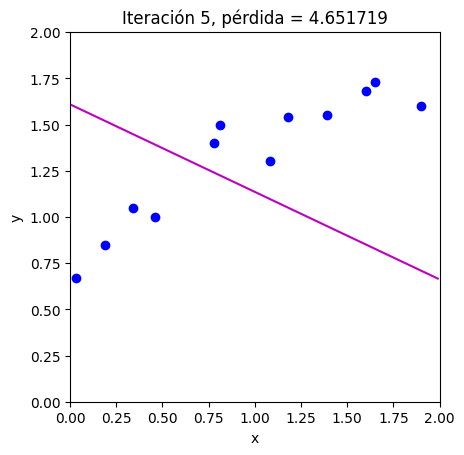

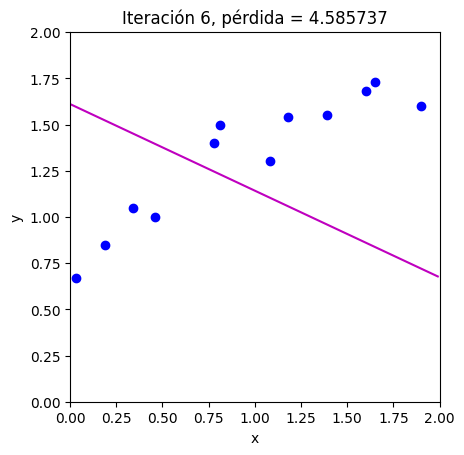

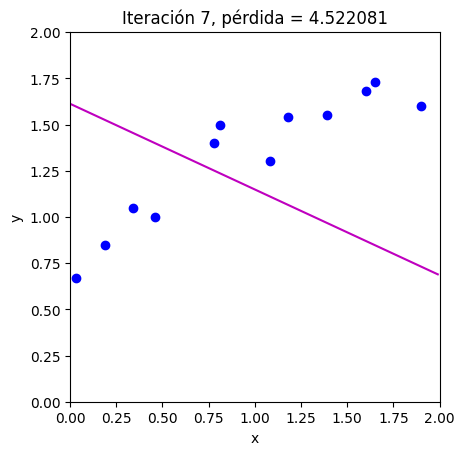

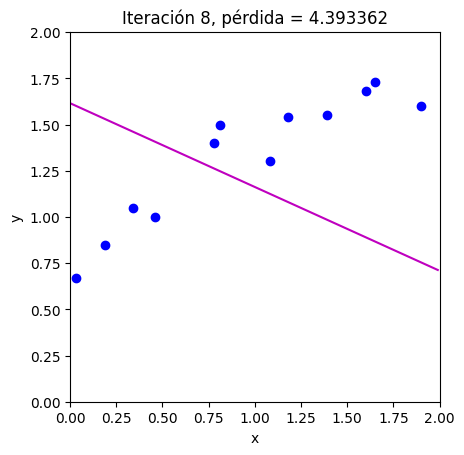

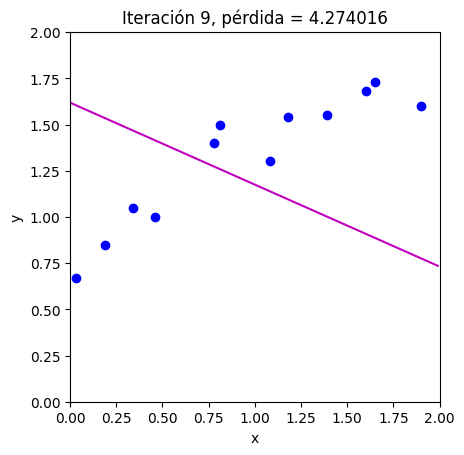

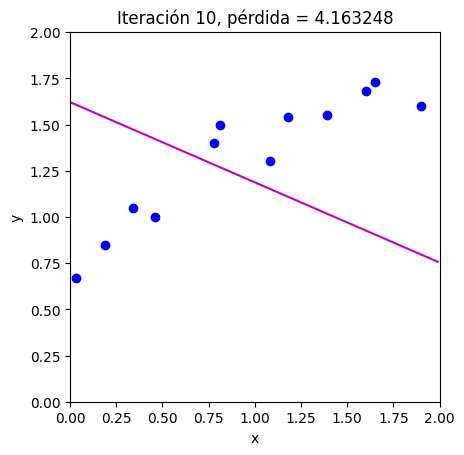

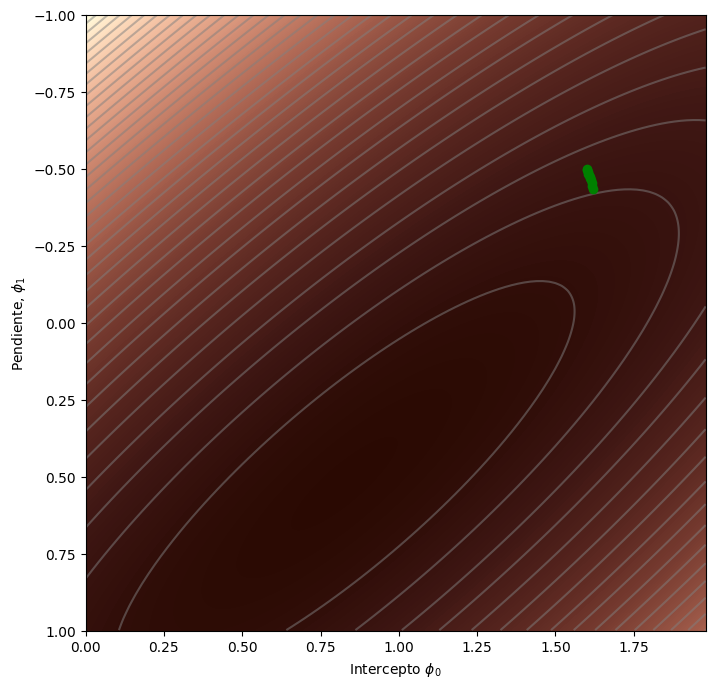

In [19]:
# Inicialice los parámetros y dibuje el modelo
n_steps = 10
phi_all = np.zeros((2,n_steps+1))
phi_all[0,0] = 1.6
phi_all[1,0] = -0.5

# Mida la pérdida y dibuje el modelo inicial
loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data,model,phi_all[:,0:1], "Parámetros iniciales, Pérdida = %f"%(loss))

# Tome repetidamente los pasos de Gradient descent
for c_step in range (n_steps):
  # Realice el paso de Gradient descent
    phi_all[:,c_step+1:c_step+2] = gradient_descent_step(phi_all[:,c_step:c_step+1],data, model)
    # Mida la pérdida y dibuje el modelo
    loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
    draw_model(data,model,phi_all[:,c_step+1], "Iteración %d, pérdida = %f"%(c_step+1,loss))

# Dibuje la trayectoria en la función de pérdida
draw_loss_function(compute_loss, data, model,phi_all)